In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, roc_auc_score
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

*Необходимо построить модель, которая выберет среди людей из набора test.csv тех, кому имеет смысл делать предложение о пожертвовании при условии, что стоимость контакта с каждым человеком фиксированная и равна 0.68 USD.*

*Считывание + Предобработка*

In [2]:
train_data = pd.read_csv('donations.csv')
test_data = pd.read_csv('test.csv')

In [3]:
def preprocess_features(df, is_train=True, imputer=None, scalers=None, encoders=None):
    df = df.copy() 
    numeric_features = ['GiftCnt36', 'GiftCntAll', 'GiftCntCard36', 'GiftCntCardAll', 
                       'GiftAvgLast', 'GiftAvg36', 'GiftAvgAll', 'GiftAvgCard36',
                       'GiftTimeLast', 'GiftTimeFirst', 'PromCnt12', 'PromCnt36', 
                       'PromCntAll', 'PromCntCard12', 'PromCntCard36', 'PromCntCardAll',
                       'StatusCatStarAll', 'DemAge', 'DemMedHomeValue', 'DemPctVeterans', 'DemMedIncome']
    
    categorical_features = ['StatusCat96NK', 'DemCluster', 'DemGender', 'DemHomeOwner']
    
    if is_train:
        imputer = SimpleImputer(strategy='median')
        df[numeric_features] = imputer.fit_transform(df[numeric_features])
    else:
        df[numeric_features] = imputer.transform(df[numeric_features])
    
    df['GiftAvg_per_Count'] = df['GiftAvgAll'] / (df['GiftCntAll'] + 1)
    df['PromResponse_Rate'] = df['GiftCntAll'] / (df['PromCntAll'] + 1)
    df['Recent_Activity'] = df['GiftCnt36'] / (df['GiftTimeLast'] + 1)
    df['Donor_Loyalty'] = df['GiftCntAll'] / (df['GiftTimeFirst'] + 1)
    df['Card_Preference'] = df['GiftCntCardAll'] / (df['GiftCntAll'] + 1)
    
    log_features = ['GiftAvgLast', 'GiftAvg36', 'GiftAvgAll', 'DemMedHomeValue', 'DemMedIncome']
    for feature in log_features:
        df[f'{feature}_log'] = np.log1p(df[feature])
    
    if is_train:
        encoders = {}
        for feature in categorical_features:
            le = LabelEncoder()
            df[feature] = le.fit_transform(df[feature].fillna('Unknown'))
            encoders[feature] = le
    else:
        for feature in categorical_features:
            unique_vals = encoders[feature].classes_
            df[feature] = df[feature].fillna('Unknown')
            df[feature] = df[feature].apply(lambda x: x if x in unique_vals else 'Unknown')
            df[feature] = encoders[feature].transform(df[feature])
    
    all_numeric = numeric_features + [f'{f}_log' for f in log_features] + \
                  ['GiftAvg_per_Count', 'PromResponse_Rate', 'Recent_Activity', 'Donor_Loyalty', 'Card_Preference']
    
    if is_train:
        scalers = {}
        for feature in all_numeric:
            scaler = StandardScaler()
            df[[feature]] = scaler.fit_transform(df[[feature]])
            scalers[feature] = scaler
    else:
        for feature in all_numeric:
            df[[feature]] = scalers[feature].transform(df[[feature]])
    
    feature_cols = all_numeric + categorical_features
    
    if is_train:
        return df[feature_cols], imputer, scalers, encoders
    else:
        return df[feature_cols]

*Интенсивность недавней активности*

*Долгосрочная лояльность донора*

*Предпочтение платежных карт*

In [4]:
feature_cols = [col for col in train_data.columns if col not in ['TargetB', 'TargetD', 'ID']]
X_train_raw = train_data[feature_cols]
y_binary = train_data['TargetB']
y_amount = train_data['TargetD'].fillna(0)
X_train, imputer, scalers, encoders = preprocess_features(X_train_raw, is_train=True)

*С помощью модели прогнозировать сумму пожертвования P_TargetD (с учетом того, что есть много нулей) и сформировать список ID,  кому стоит делать предложение, у кого ожидаемая сумма P_TargetD> 0.68.*

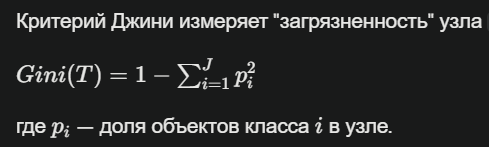

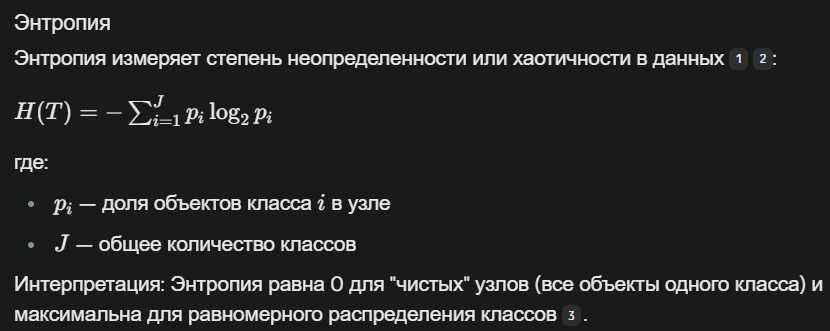

*Обучение модели*

In [5]:
X_tr, X_val, y_bin_tr, y_bin_val, y_amt_tr, y_amt_val = train_test_split(
    X_train, y_binary, y_amount, test_size=0.2, random_state=42, stratify=y_binary)

In [ ]:
rf_params = {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}

binary_model = HalvingGridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='roc_auc', 
    random_state=42,
    n_jobs=-1)

binary_model.fit(X_tr, y_bin_tr)
best_binary_model = binary_model.best_estimator_

In [7]:
donor_mask = y_bin_tr == 1
X_tr_donors = X_tr[donor_mask]
y_amt_tr_donors = y_amt_tr[donor_mask]

rf_reg_params = {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}

amount_model = HalvingGridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_reg_params,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1)

amount_model.fit(X_tr_donors, y_amt_tr_donors)
best_amount_model = amount_model.best_estimator_

*RandomForestClassifier предсказывает вероятность пожертвования (будет ли человек жертвовать)*

*RandomForestRegressor предсказывает размер пожертвования среди тех, кто жертвует*

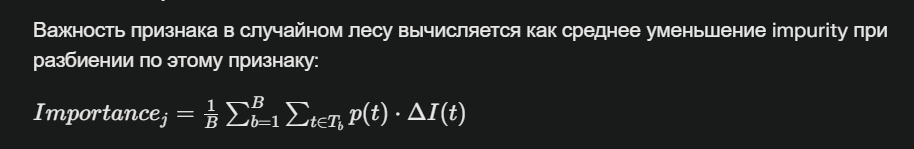

*Обработка тестовых данных*

In [8]:
X_test_raw = test_data[feature_cols]
X_test = preprocess_features(X_test_raw, is_train=False, imputer=imputer, scalers=scalers, encoders=encoders)

In [9]:
prob_donate = best_binary_model.predict_proba(X_test)[:, 1]
pred_amount = best_amount_model.predict(X_test)
pred_amount = np.maximum(pred_amount, 0)

contact_cost = 0.68
expected_profit = prob_donate * pred_amount - contact_cost
risk_adjusted_profit = prob_donate * pred_amount - contact_cost / prob_donate
roi = (prob_donate * pred_amount - contact_cost) / contact_cost
confidence_weighted = prob_donate * pred_amount * (2 * prob_donate - 1)

ensemble_score = (
    0.4 * (expected_profit / expected_profit.std()) +
    0.3 * (roi / roi.std()) +
    0.3 * (confidence_weighted / confidence_weighted.std()))

*Прогноз*

In [ ]:
sorted_indices = np.argsort(ensemble_score)[::-1]

profitable_mask = expected_profit > 0
profitable_indices = np.where(profitable_mask)[0]

top_threshold = np.percentile(ensemble_score, 80)
elite_mask = ensemble_score > top_threshold
elite_indices = np.where(elite_mask)[0]

candidates = np.intersect1d(profitable_indices, elite_indices)

if len(candidates) < 1000:
    top_threshold = np.percentile(ensemble_score, 70)
    elite_mask = ensemble_score > top_threshold
    elite_indices = np.where(elite_mask)[0]
    candidates = np.intersect1d(profitable_indices, elite_indices)

selected_indices = candidates
selected_ids = test_data.iloc[selected_indices]['ID'].values
ids_list = list(selected_ids)

*Результаты*

In [11]:
total_expected_profit = expected_profit[selected_indices].sum()
avg_profit_per_person = total_expected_profit / len(selected_ids)
selection_rate = len(ids_list) / len(test_data)

print(f"Отобрано клиентов: {len(ids_list):,}")
print(f"Ожидаемая прибыль: ${total_expected_profit:,.2f}")
print(f"Вероятность доната: {prob_donate[selected_indices].mean():.3f}")
print(f"Средняя ожидаемая сумма: ${pred_amount[selected_indices].mean():.2f}")

Отобрано клиентов: 19,274
Ожидаемая прибыль: $247,981.00
Вероятность доната: 0.517
Средняя ожидаемая сумма: $27.46


In [12]:
results_df = pd.DataFrame({'ID': ids_list})
results_df = results_df.sort_values('ID').reset_index(drop=True)
results_df.to_csv('selected_customers.csv', index=False)